Features in Image 1: 2000
Features in Image 2: 2000
Good matches: 484


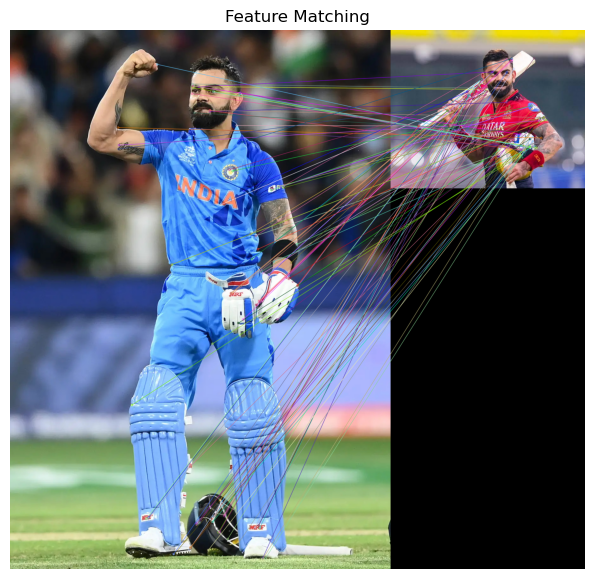

Camera Matrix:
[[1.20e+03 0.00e+00 6.00e+02]
 [0.00e+00 1.20e+03 8.51e+02]
 [0.00e+00 0.00e+00 1.00e+00]]
Essential Matrix:
[[-0.41751342 -0.53546737 -0.07085199]
 [ 0.53522223 -0.28561951 -0.18942748]
 [ 0.14629058 -0.30771937 -0.11798722]]
Inlier points: 26
Rotation Matrix:
[[-0.79098528  0.6091029   0.05775768]
 [-0.53677006 -0.64553666 -0.54328659]
 [-0.29363274 -0.46073429  0.83755819]]

Translation Vector:
[[-0.26052727]
 [-0.43835122]
 [ 0.86021727]]

3D Points:
[[ 2.0985883e-01 -1.6368012e-01  1.0774670e+00]
 [ 8.0882668e-02  3.7802108e-02  7.2583187e-01]
 [-1.8324634e-01  2.5784862e-01 -8.6915267e-01]
 [-1.8862896e-02  8.2287014e-02  1.4290072e-01]
 [-8.2097530e-02  1.2664542e-01 -4.2678085e-01]
 [-1.5791748e+00  1.9490533e+00 -1.1177772e+01]
 [ 1.8609552e-04  1.6844885e-02 -3.2130130e-02]
 [ 1.2883104e-03  1.2445361e-02  2.2182779e-02]
 [ 1.1709275e-02 -7.4213324e-03  1.0753139e-01]
 [ 2.4731865e-03  4.5715939e-02  8.3226606e-02]]

Number of 3D points: 26


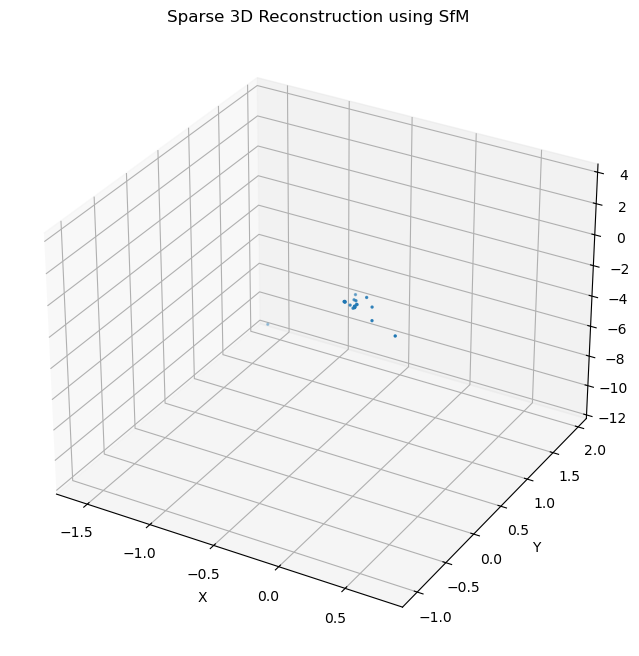

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Read two color images
# --------------------------------------------------

img1 = cv2.imread("348106.jpg")
img2 = cv2.imread("VK18.jpg")

# Convert BGR to RGB for displaying
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# --------------------------------------------------
# 2. Convert images to grayscale for feature detection
# --------------------------------------------------

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# --------------------------------------------------
# 3. Detect feature points using ORB
# --------------------------------------------------

orb = cv2.ORB_create(nfeatures=2000)

keypoints1, descriptors1 = orb.detectAndCompute(gray1, None)
keypoints2, descriptors2 = orb.detectAndCompute(gray2, None)

print("Features in Image 1:", len(keypoints1))
print("Features in Image 2:", len(keypoints2))

# --------------------------------------------------
# 4. Match feature points
# --------------------------------------------------

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(descriptors1, descriptors2)

# Sort matches according to distance
matches = sorted(matches, key=lambda x: x.distance)

# Keep best 500 matches
good_matches = matches[:500]

print("Good matches:", len(good_matches))

# --------------------------------------------------
# 5. Display feature matching
# --------------------------------------------------

match_image = cv2.drawMatches(
    img1,
    keypoints1,
    img2,
    keypoints2,
    good_matches[:100],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15, 7))
plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
plt.title("Feature Matching")
plt.axis("off")
plt.show()

# --------------------------------------------------
# 6. Get coordinates of matched points
# --------------------------------------------------

pts1 = np.float32([
    keypoints1[m.queryIdx].pt
    for m in good_matches
])

pts2 = np.float32([
    keypoints2[m.trainIdx].pt
    for m in good_matches
])

# --------------------------------------------------
# 7. Camera intrinsic matrix
# --------------------------------------------------

h, w = gray1.shape

focal_length = w

K = np.array([
    [focal_length, 0, w / 2],
    [0, focal_length, h / 2],
    [0, 0, 1]
], dtype=np.float64)

print("Camera Matrix:")
print(K)

# --------------------------------------------------
# 8. Calculate Essential Matrix
# --------------------------------------------------

E, mask = cv2.findEssentialMat(
    pts1,
    pts2,
    K,
    method=cv2.RANSAC,
    prob=0.999,
    threshold=1.0
)

print("Essential Matrix:")
print(E)

# Keep only inlier points
pts1_inliers = pts1[mask.ravel() == 1]
pts2_inliers = pts2[mask.ravel() == 1]

print("Inlier points:", len(pts1_inliers))

# --------------------------------------------------
# 9. Recover camera rotation and translation
# --------------------------------------------------

_, R, t, mask_pose = cv2.recoverPose(
    E,
    pts1_inliers,
    pts2_inliers,
    K
)

print("Rotation Matrix:")
print(R)

print("\nTranslation Vector:")
print(t)

# --------------------------------------------------
# 10. Create camera projection matrices
# --------------------------------------------------

P1 = K @ np.hstack((
    np.eye(3),
    np.zeros((3, 1))
))

P2 = K @ np.hstack((
    R,
    t
))

# --------------------------------------------------
# 11. Triangulation
# --------------------------------------------------

points_4D = cv2.triangulatePoints(
    P1,
    P2,
    pts1_inliers.T,
    pts2_inliers.T
)

# Convert homogeneous coordinates to 3D
points_3D = points_4D[:3] / points_4D[3]

points_3D = points_3D.T

print("\n3D Points:")
print(points_3D[:10])

print("\nNumber of 3D points:", len(points_3D))

# --------------------------------------------------
# 12. Display 3D reconstructed points
# --------------------------------------------------

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    points_3D[:, 0],
    points_3D[:, 1],
    points_3D[:, 2],
    s=2
)

ax.set_title("Sparse 3D Reconstruction using SfM")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()